In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

os.listdir('/content/drive/MyDrive')

['Colab Notebooks',
 'Achievements ',
 'DOC-Forage...pdf',
 'SkillsCert20260707-7-fwctij.pdf',
 'SkillsCert20260707-7-lpayu3.pdf',
 'DOC-mongoDB..pdf',
 'DOC-Microsoft..pdf',
 'gMTdCXwDdLYoXZ3wG_ifobHAoMjQs9s6bKS_QFCjzzkoNtXwsSoXH_1754462757836_completion_certificate (1).pdf',
 'fAuNBibfF4dzrgtDY_8eNRcRqBZM9HLvwGw_69b16f2986bcbe7ef0515b7c_1775149591177_completion_certificate (1) (1).pdf',
 'EregFenDKXDDeTGR2_BotenCEjm3LFxtq9A_69b16f2986bcbe7ef0515b7c_1775148509801_completion_certificate.pdf',
 'IBMDesign20260707-7-ipy6l8.pdf',
 'Document from ~𝗞ɑ𝔯ɑ𝖓 (2)',
 'Document from ~𝗞ɑ𝔯ɑ𝖓 (1)',
 'Document from ~𝗞ɑ𝔯ɑ𝖓']

In [3]:
import os

os.listdir('/content/drive/MyDrive')

['Colab Notebooks',
 'Achievements ',
 'DOC-Forage...pdf',
 'SkillsCert20260707-7-fwctij.pdf',
 'SkillsCert20260707-7-lpayu3.pdf',
 'DOC-mongoDB..pdf',
 'DOC-Microsoft..pdf',
 'gMTdCXwDdLYoXZ3wG_ifobHAoMjQs9s6bKS_QFCjzzkoNtXwsSoXH_1754462757836_completion_certificate (1).pdf',
 'fAuNBibfF4dzrgtDY_8eNRcRqBZM9HLvwGw_69b16f2986bcbe7ef0515b7c_1775149591177_completion_certificate (1) (1).pdf',
 'EregFenDKXDDeTGR2_BotenCEjm3LFxtq9A_69b16f2986bcbe7ef0515b7c_1775148509801_completion_certificate.pdf',
 'IBMDesign20260707-7-ipy6l8.pdf',
 'Document from ~𝗞ɑ𝔯ɑ𝖓 (2)',
 'Document from ~𝗞ɑ𝔯ɑ𝖓 (1)',
 'Document from ~𝗞ɑ𝔯ɑ𝖓',
 'marketing_campaign (1).csv',
 'marketing_campaign.csv']

In [4]:
import pandas as pd

file_path = '/content/drive/MyDrive/marketing_campaign.csv'

df = pd.read_csv(file_path, sep='\t')

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [5]:
print("Rows and columns:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Rows and columns: (2240, 29)

Column names:
['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']


In [6]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


In [7]:
df.dropna(subset=['Income'], inplace=True)

print("Dataset shape after cleaning:", df.shape)
print("Missing Income values:", df['Income'].isnull().sum())

Dataset shape after cleaning: (2216, 29)
Missing Income values: 0


In [8]:
df['Dt_Customer'] = pd.to_datetime(
    df['Dt_Customer'],
    dayfirst=True
)

print(df['Dt_Customer'].dtype)

datetime64[ns]


In [9]:
from datetime import datetime

# Age
df['Age'] = 2026 - df['Year_Birth']

# Total children
df['TotalChildren'] = df['Kidhome'] + df['Teenhome']

# Total spending
spending_cols = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

df['TotalSpending'] = df[spending_cols].sum(axis=1)

# Customer tenure in days
today = pd.Timestamp('2026-09-13')
df['CustomerTenureDays'] = (today - df['Dt_Customer']).dt.days

print(df[['Age', 'TotalChildren', 'TotalSpending',
          'CustomerTenureDays']].head())

   Age  TotalChildren  TotalSpending  CustomerTenureDays
0   69              0           1617                5122
1   72              2             27                4572
2   61              0            776                4771
3   42              1             53                4598
4   45              1            422                4620


In [10]:
campaign_cols = [
    'AcceptedCmp1',
    'AcceptedCmp2',
    'AcceptedCmp3',
    'AcceptedCmp4',
    'AcceptedCmp5',
    'Response'
]

df['AcceptedAny'] = (df[campaign_cols].sum(axis=1) > 0).astype(int)

print(df['AcceptedAny'].value_counts())

AcceptedAny
0    1611
1     605
Name: count, dtype: int64


In [11]:
df[['Age', 'Income', 'TotalSpending',
    'NumWebPurchases', 'NumStorePurchases',
    'NumWebVisitsMonth', 'Recency']].describe()

,Age,Income,TotalSpending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000
mean,57.179603,52247.251354,607.075361,4.085289,5.800993,5.319043,49.012635
std,11.985554,25173.076661,602.900476,2.740951,3.250785,2.425359,28.948352
min,30.000000,1730.000000,5.000000,0.000000,0.000000,0.000000,0.000000
25%,49.000000,35303.000000,69.000000,2.000000,3.000000,3.000000,24.000000
50%,56.000000,51381.500000,396.500000,4.000000,5.000000,6.000000,49.000000
75%,67.000000,68522.000000,1048.000000,6.000000,8.000000,7.000000,74.000000
max,133.000000,666666.000000,2525.000000,27.000000,13.000000,20.000000,99.000000


In [12]:
print("Age range:", df['Age'].min(), "to", df['Age'].max())
print("Income range:", df['Income'].min(), "to", df['Income'].max())

print("\nCustomers with Age > 100:")
print(df[df['Age'] > 100][['Year_Birth', 'Age', 'Income']])

Age range: 30 to 133
Income range: 1730.0 to 666666.0

Customers with Age > 100:
     Year_Birth  Age   Income
192        1900  126  36640.0
239        1893  133  60182.0
339        1899  127  83532.0


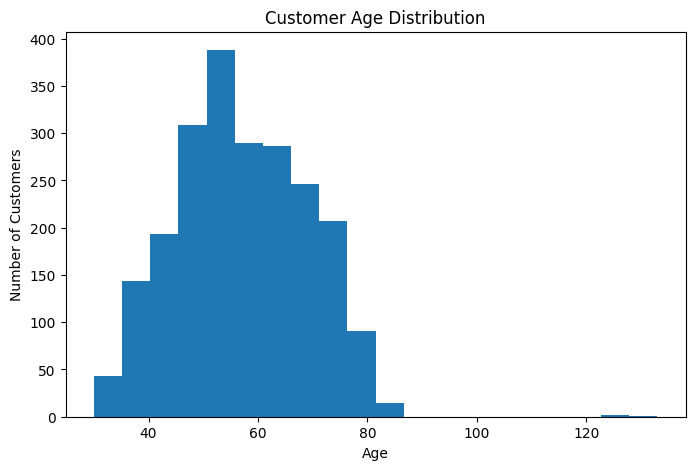

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df['Age'], bins=20)
plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()

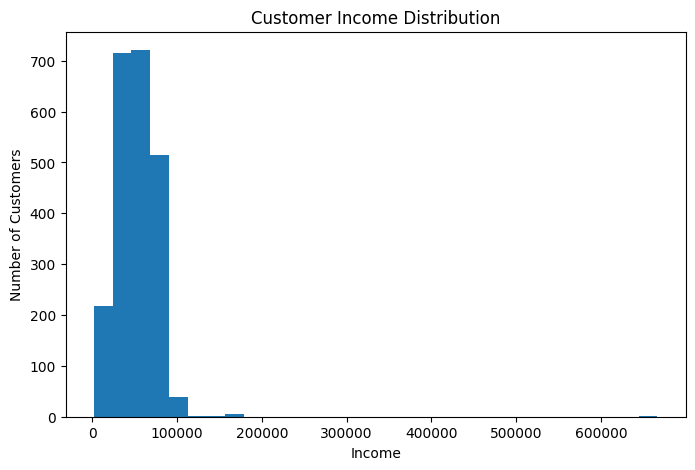

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(df['Income'], bins=30)
plt.title('Customer Income Distribution')
plt.xlabel('Income')
plt.ylabel('Number of Customers')
plt.show()

In [15]:
corr_cols = [
    'Income',
    'TotalSpending',
    'NumWebPurchases',
    'NumStorePurchases',
    'NumWebVisitsMonth',
    'Recency'
]

correlation = df[corr_cols].corr()

print(correlation.round(2))

                   Income  TotalSpending  NumWebPurchases  NumStorePurchases  \
Income               1.00           0.67             0.39               0.53   
TotalSpending        0.67           1.00             0.53               0.68   
NumWebPurchases      0.39           0.53             1.00               0.52   
NumStorePurchases    0.53           0.68             0.52               1.00   
NumWebVisitsMonth   -0.55          -0.50            -0.05              -0.43   
Recency             -0.00           0.02            -0.01              -0.00   

                   NumWebVisitsMonth  Recency  
Income                         -0.55    -0.00  
TotalSpending                  -0.50     0.02  
NumWebPurchases                -0.05    -0.01  
NumStorePurchases              -0.43    -0.00  
NumWebVisitsMonth               1.00    -0.02  
Recency                        -0.02     1.00  


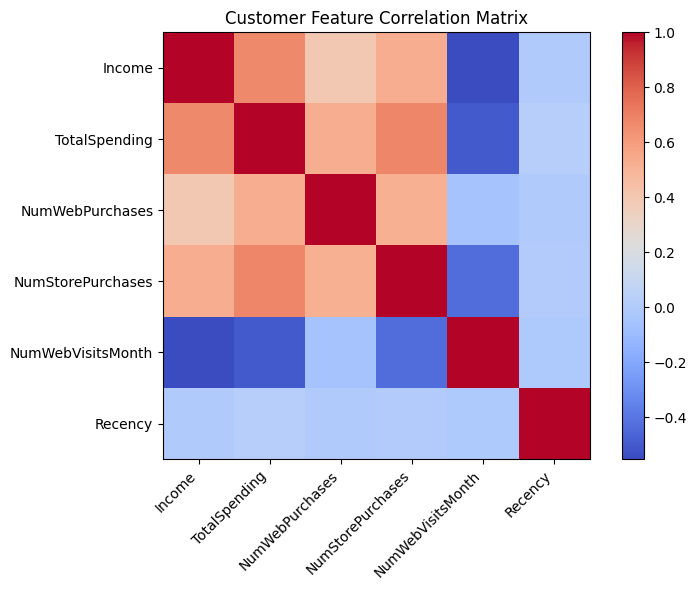

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.imshow(correlation, cmap='coolwarm')
plt.colorbar()

plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha='right')
plt.yticks(range(len(corr_cols)), corr_cols)

plt.title('Customer Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [17]:
education_spending = (
    df.groupby('Education')['TotalSpending']
      .mean()
      .sort_values(ascending=False)
)

print(education_spending.round(2))

Education
PhD           676.73
Graduation    621.69
Master        609.77
2n Cycle      494.93
Basic          81.80
Name: TotalSpending, dtype: float64


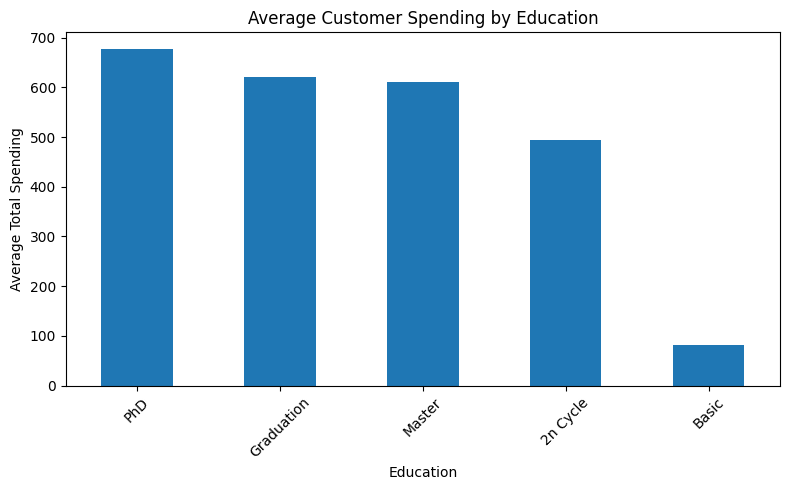

In [18]:
plt.figure(figsize=(8, 5))
education_spending.plot(kind='bar')
plt.title('Average Customer Spending by Education')
plt.xlabel('Education')
plt.ylabel('Average Total Spending')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
features = [
    'Age',
    'Income',
    'TotalSpending',
    'NumWebPurchases',
    'NumStorePurchases',
    'NumWebVisitsMonth',
    'Recency'
]

X = df[features].copy()

print("Features used for clustering:")
print(features)

print("\nShape of X:", X.shape)
print("\nMissing values:")
print(X.isnull().sum())

Features used for clustering:
['Age', 'Income', 'TotalSpending', 'NumWebPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Recency']

Shape of X: (2216, 7)

Missing values:
Age                  0
Income               0
TotalSpending        0
NumWebPurchases      0
NumStorePurchases    0
NumWebVisitsMonth    0
Recency              0
dtype: int64


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (2216, 7)


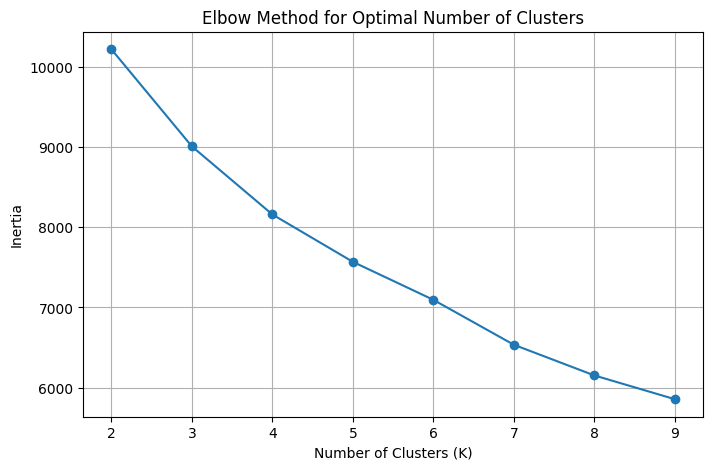

In [21]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []

for k in range(2, 10):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 10), inertias, marker='o')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(range(2, 10))
plt.grid(True)
plt.show()

In [22]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 10):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

for k, score in zip(range(2, 10), silhouette_scores):
    print(f"K = {k}: Silhouette Score = {score:.4f}")

K = 2: Silhouette Score = 0.3215
K = 3: Silhouette Score = 0.2645
K = 4: Silhouette Score = 0.1947
K = 5: Silhouette Score = 0.1916
K = 6: Silhouette Score = 0.1839
K = 7: Silhouette Score = 0.1850
K = 8: Silhouette Score = 0.1848
K = 9: Silhouette Score = 0.1849


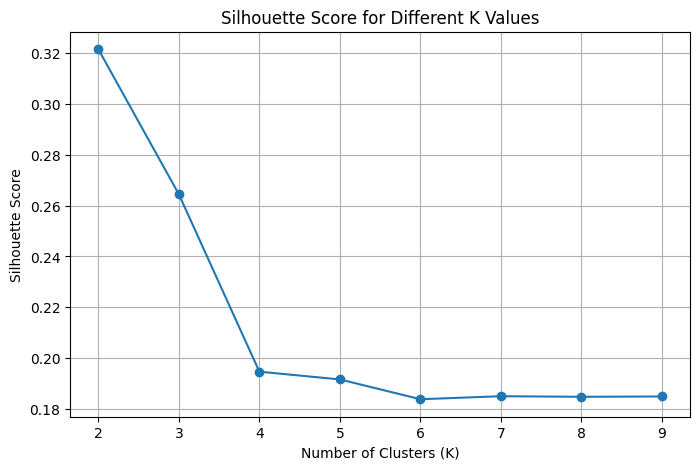

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 10), silhouette_scores, marker='o')
plt.title('Silhouette Score for Different K Values')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 10))
plt.grid(True)
plt.show()

In [24]:
final_k = 6

kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

print("Cluster sizes:")
print(df['Cluster'].value_counts().sort_index())

Cluster sizes:
Cluster
0    381
1    417
2    330
3    446
4    328
5    314
Name: count, dtype: int64


In [25]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 10):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

for k, score in zip(range(2, 10), silhouette_scores):
    print(f"K = {k}: Silhouette Score = {score:.4f}")

K = 2: Silhouette Score = 0.3215
K = 3: Silhouette Score = 0.2645
K = 4: Silhouette Score = 0.1947
K = 5: Silhouette Score = 0.1916
K = 6: Silhouette Score = 0.1839
K = 7: Silhouette Score = 0.1850
K = 8: Silhouette Score = 0.1848
K = 9: Silhouette Score = 0.1849


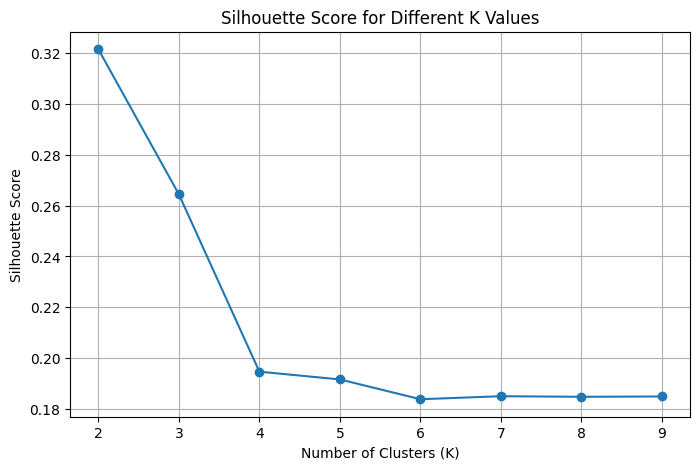

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 10),
    silhouette_scores,
    marker='o'
)

plt.title('Silhouette Score for Different K Values')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 10))
plt.grid(True)
plt.show()

In [27]:
final_k = 6

kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

print("Cluster sizes:")
print(df['Cluster'].value_counts().sort_index())

Cluster sizes:
Cluster
0    381
1    417
2    330
3    446
4    328
5    314
Name: count, dtype: int64


In [28]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("Total variance explained:",
      pca.explained_variance_ratio_.sum())

Explained variance ratio:
[0.43281928 0.1441598 ]
Total variance explained: 0.5769790800423813


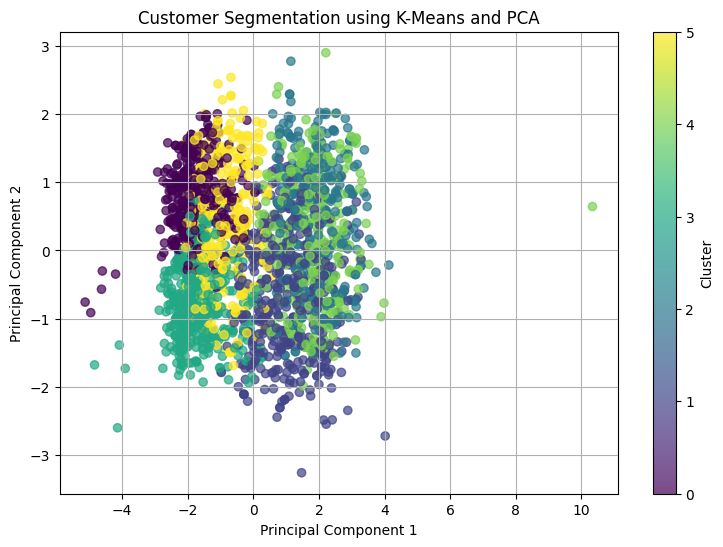

In [29]:
plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['Cluster'],
    alpha=0.7
)

plt.title('Customer Segmentation using K-Means and PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Cluster')
plt.grid(True)
plt.show()

In [30]:
cluster_profile = df.groupby('Cluster')[
    [
        'Age',
        'Income',
        'TotalSpending',
        'NumWebPurchases',
        'NumStorePurchases',
        'NumWebVisitsMonth',
        'Recency'
    ]
].mean()

cluster_profile.round(2)

,Age,Income,TotalSpending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,,
0,50.01,32433.73,111.70,2.28,3.17,7.08,75.81
1,59.86,59979.42,896.01,8.01,7.88,6.40,46.19
2,70.32,73497.37,1200.71,4.65,8.55,2.75,51.24
3,49.98,33412.62,120.34,2.22,3.33,6.59,23.31
4,47.12,78234.23,1296.47,4.58,8.53,2.66,50.35
5,69.25,43293.81,171.78,2.60,4.01,5.42,53.00


Cluster
0    381
1    417
2    330
3    446
4    328
5    314
Name: count, dtype: int64


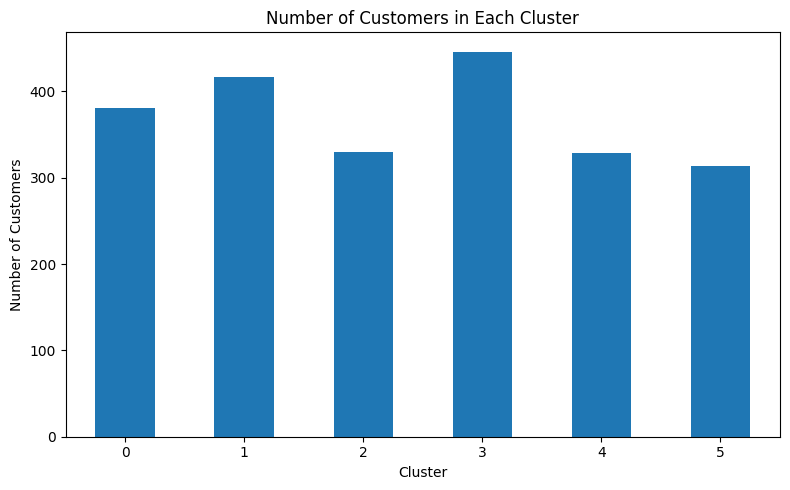

In [31]:
cluster_counts = df['Cluster'].value_counts().sort_index()

print(cluster_counts)

plt.figure(figsize=(8, 5))

cluster_counts.plot(kind='bar')

plt.title('Number of Customers in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [32]:
profile = df.groupby('Cluster')[
    [
        'Age',
        'Income',
        'TotalSpending',
        'NumWebPurchases',
        'NumStorePurchases',
        'NumWebVisitsMonth',
        'Recency'
    ]
].mean()

profile['CustomerCount'] = df['Cluster'].value_counts().sort_index()

profile.round(2)

,Age,Income,TotalSpending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency,CustomerCount
Cluster,,,,,,,,
0,50.01,32433.73,111.70,2.28,3.17,7.08,75.81,381
1,59.86,59979.42,896.01,8.01,7.88,6.40,46.19,417
2,70.32,73497.37,1200.71,4.65,8.55,2.75,51.24,330
3,49.98,33412.62,120.34,2.22,3.33,6.59,23.31,446
4,47.12,78234.23,1296.47,4.58,8.53,2.66,50.35,328
5,69.25,43293.81,171.78,2.60,4.01,5.42,53.00,314


In [33]:
profile.round(2)

,Age,Income,TotalSpending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency,CustomerCount
Cluster,,,,,,,,
0,50.01,32433.73,111.70,2.28,3.17,7.08,75.81,381
1,59.86,59979.42,896.01,8.01,7.88,6.40,46.19,417
2,70.32,73497.37,1200.71,4.65,8.55,2.75,51.24,330
3,49.98,33412.62,120.34,2.22,3.33,6.59,23.31,446
4,47.12,78234.23,1296.47,4.58,8.53,2.66,50.35,328
5,69.25,43293.81,171.78,2.60,4.01,5.42,53.00,314


In [41]:
print(profile.round(2).to_string())

           Age    Income  TotalSpending  NumWebPurchases  NumStorePurchases  NumWebVisitsMonth  Recency  CustomerCount
Cluster                                                                                                               
0        50.01  32433.73         111.70             2.28               3.17               7.08    75.81            381
1        59.86  59979.42         896.01             8.01               7.88               6.40    46.19            417
2        70.32  73497.37        1200.71             4.65               8.55               2.75    51.24            330
3        49.98  33412.62         120.34             2.22               3.33               6.59    23.31            446
4        47.12  78234.23        1296.47             4.58               8.53               2.66    50.35            328
5        69.25  43293.81         171.78             2.60               4.01               5.42    53.00            314


In [42]:
print("Customers in each cluster:")
print(df['Cluster'].value_counts().sort_index())

Customers in each cluster:
Cluster
0    381
1    417
2    330
3    446
4    328
5    314
Name: count, dtype: int64


In [34]:
profile.round(2)

,Age,Income,TotalSpending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency,CustomerCount
Cluster,,,,,,,,
0,50.01,32433.73,111.70,2.28,3.17,7.08,75.81,381
1,59.86,59979.42,896.01,8.01,7.88,6.40,46.19,417
2,70.32,73497.37,1200.71,4.65,8.55,2.75,51.24,330
3,49.98,33412.62,120.34,2.22,3.33,6.59,23.31,446
4,47.12,78234.23,1296.47,4.58,8.53,2.66,50.35,328
5,69.25,43293.81,171.78,2.60,4.01,5.42,53.00,314


In [43]:
print("PCA explained variance:")
print(pca.explained_variance_ratio_)

print("\nTotal variance explained:",
      round(pca.explained_variance_ratio_.sum(), 4))

PCA explained variance:
[0.43281928 0.1441598 ]

Total variance explained: 0.577


In [44]:
print(profile.round(2).to_string())

           Age    Income  TotalSpending  NumWebPurchases  NumStorePurchases  NumWebVisitsMonth  Recency  CustomerCount
Cluster                                                                                                               
0        50.01  32433.73         111.70             2.28               3.17               7.08    75.81            381
1        59.86  59979.42         896.01             8.01               7.88               6.40    46.19            417
2        70.32  73497.37        1200.71             4.65               8.55               2.75    51.24            330
3        49.98  33412.62         120.34             2.22               3.33               6.59    23.31            446
4        47.12  78234.23        1296.47             4.58               8.53               2.66    50.35            328
5        69.25  43293.81         171.78             2.60               4.01               5.42    53.00            314


In [45]:
print("Customers in each cluster:")
print(df['Cluster'].value_counts().sort_index())

Customers in each cluster:
Cluster
0    381
1    417
2    330
3    446
4    328
5    314
Name: count, dtype: int64


In [46]:
print(profile.loc[5].round(2).to_string())

Age                     69.25
Income               43293.81
TotalSpending          171.78
NumWebPurchases          2.60
NumStorePurchases        4.01
NumWebVisitsMonth        5.42
Recency                 53.00
CustomerCount          314.00


In [47]:
summary = profile.round(2).copy()

summary['CustomerShare_%'] = (
    summary['CustomerCount'] / len(df) * 100
).round(2)

print(summary.to_string())

           Age    Income  TotalSpending  NumWebPurchases  NumStorePurchases  NumWebVisitsMonth  Recency  CustomerCount  CustomerShare_%
Cluster                                                                                                                                
0        50.01  32433.73         111.70             2.28               3.17               7.08    75.81            381            17.19
1        59.86  59979.42         896.01             8.01               7.88               6.40    46.19            417            18.82
2        70.32  73497.37        1200.71             4.65               8.55               2.75    51.24            330            14.89
3        49.98  33412.62         120.34             2.22               3.33               6.59    23.31            446            20.13
4        47.12  78234.23        1296.47             4.58               8.53               2.66    50.35            328            14.80
5        69.25  43293.81         171.78         

In [48]:
profile_file = model_folder + '/cluster_profile.csv'

summary.to_csv(profile_file)

print("Cluster profile saved successfully!")
print(profile_file)

Cluster profile saved successfully!
/content/drive/MyDrive/Customer_Segmentation_Project/cluster_profile.csv


In [49]:
cluster_names = {
    0: 'Low-Value / Inactive Customers',
    1: 'Regular High-Value Customers',
    2: 'Affluent Older Customers',
    3: 'Recent Low-Value Customers',
    4: 'Premium High-Value Customers',
    5: 'Older Low-Value Customers'
}

df['Segment'] = df['Cluster'].map(cluster_names)

print(df[['Cluster', 'Segment']].drop_duplicates().sort_values('Cluster'))

    Cluster                         Segment
4         0  Low-Value / Inactive Customers
0         1    Regular High-Value Customers
12        2        Affluent Older Customers
3         3      Recent Low-Value Customers
36        4    Premium High-Value Customers
1         5       Older Low-Value Customers


In [50]:
business_summary = df.groupby(['Cluster', 'Segment']).agg(
    Customers=('ID', 'count'),
    Avg_Age=('Age', 'mean'),
    Avg_Income=('Income', 'mean'),
    Avg_Spending=('TotalSpending', 'mean'),
    Avg_Web_Purchases=('NumWebPurchases', 'mean'),
    Avg_Store_Purchases=('NumStorePurchases', 'mean'),
    Avg_Web_Visits=('NumWebVisitsMonth', 'mean'),
    Avg_Recency=('Recency', 'mean')
).round(2)

print(business_summary.to_string())

                                        Customers  Avg_Age  Avg_Income  Avg_Spending  Avg_Web_Purchases  Avg_Store_Purchases  Avg_Web_Visits  Avg_Recency
Cluster Segment                                                                                                                                          
0       Low-Value / Inactive Customers        381    50.01    32433.73        111.70               2.28                 3.17            7.08        75.81
1       Regular High-Value Customers          417    59.86    59979.42        896.01               8.01                 7.88            6.40        46.19
2       Affluent Older Customers              330    70.32    73497.37       1200.71               4.65                 8.55            2.75        51.24
3       Recent Low-Value Customers            446    49.98    33412.62        120.34               2.22                 3.33            6.59        23.31
4       Premium High-Value Customers          328    47.12    78234.23      

In [51]:
final_file = model_folder + '/final_customer_segments.csv'

df.to_csv(final_file, index=False)

print("Final segmented dataset saved successfully!")
print(final_file)

Final segmented dataset saved successfully!
/content/drive/MyDrive/Customer_Segmentation_Project/final_customer_segments.csv


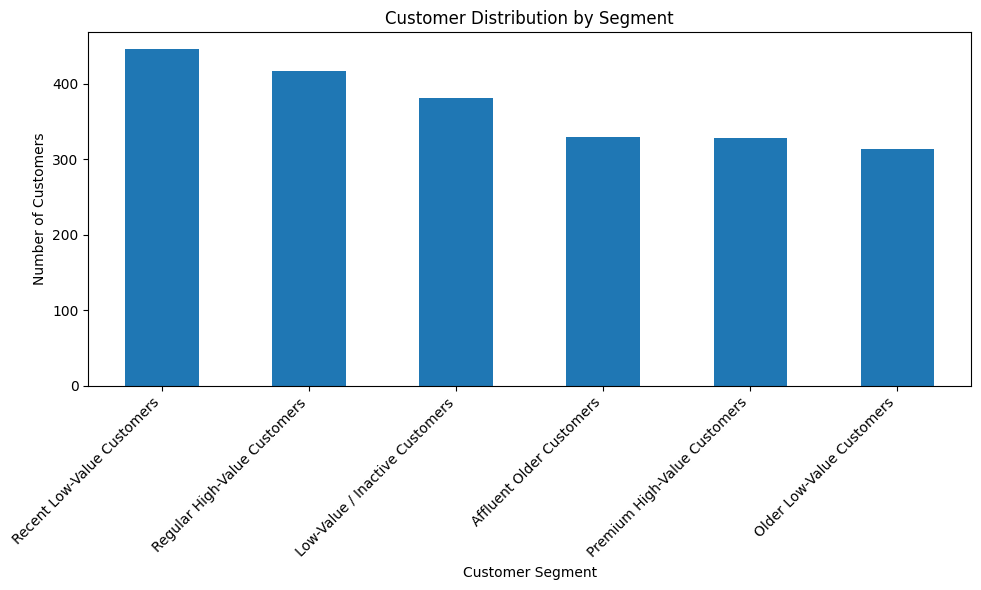

In [52]:
segment_counts = df['Segment'].value_counts()

plt.figure(figsize=(10, 6))

segment_counts.plot(kind='bar')

plt.title('Customer Distribution by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [53]:
## Business Recommendations

### 1. Premium High-Value Customers
These customers have the highest income and spending levels.
- Provide premium offers and loyalty rewards.
- Recommend high-value products.
- Focus on customer retention.

### 2. Affluent Older Customers
These customers have high income and spending but are older.
- Provide personalized product recommendations.
- Offer loyalty benefits.
- Use targeted communication suited to their preferences.

### 3. Regular High-Value Customers
These customers show strong purchasing activity and represent an important revenue segment.
- Encourage repeat purchases.
- Provide personalized promotions.
- Introduce cross-selling opportunities.

### 4. Recent Low-Value Customers
These customers have relatively low spending but recent purchasing activity.
- Encourage their second and third purchases.
- Provide introductory offers.
- Recommend relevant products based on purchase behavior.

### 5. Low-Value / Inactive Customers
These customers have low spending and signs of reduced recent activity.
- Use re-engagement campaigns.
- Offer limited-time discounts.
- Identify reasons for inactivity.

### 6. Older Low-Value Customers
These customers are older and have relatively low spending.
- Use personalized and simple promotional campaigns.
- Focus on products relevant to their purchasing behavior.
- Avoid excessive marketing frequency.

SyntaxError: invalid syntax (3401343380.py, line 4)

## Business Recommendations

### 1. Premium High-Value Customers
These customers have the highest income and spending levels.
- Provide premium offers and loyalty rewards.
- Recommend high-value products.
- Focus on customer retention.

### 2. Affluent Older Customers
These customers have high income and spending but are older.
- Provide personalized product recommendations.
- Offer loyalty benefits.
- Use targeted communication suited to their preferences.

### 3. Regular High-Value Customers
These customers show strong purchasing activity and represent an important revenue segment.
- Encourage repeat purchases.
- Provide personalized promotions.
- Introduce cross-selling opportunities.

### 4. Recent Low-Value Customers
These customers have relatively low spending but recent purchasing activity.
- Encourage their second and third purchases.
- Provide introductory offers.
- Recommend relevant products based on purchase behavior.

### 5. Low-Value / Inactive Customers
These customers have low spending and signs of reduced recent activity.
- Use re-engagement campaigns.
- Offer limited-time discounts.
- Identify reasons for inactivity.

### 6. Older Low-Value Customers
These customers are older and have relatively low spending.
- Use personalized and simple promotional campaigns.
- Focus on products relevant to their purchasing behavior.
- Avoid excessive marketing frequency.

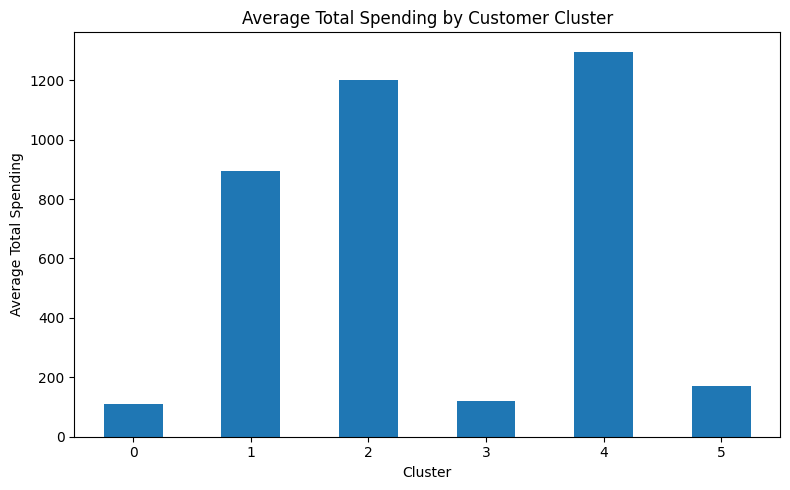

In [35]:
cluster_spending = df.groupby('Cluster')['TotalSpending'].mean()

plt.figure(figsize=(8, 5))

cluster_spending.plot(kind='bar')

plt.title('Average Total Spending by Customer Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Total Spending')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

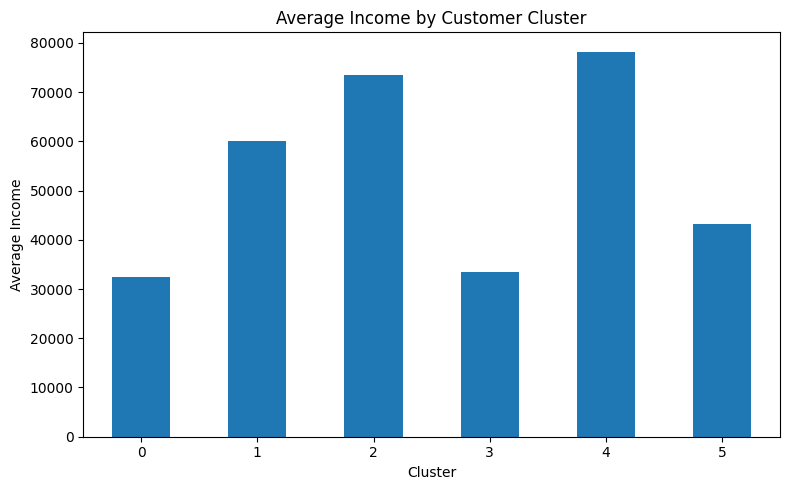

In [36]:
cluster_income = df.groupby('Cluster')['Income'].mean()

plt.figure(figsize=(8, 5))

cluster_income.plot(kind='bar')

plt.title('Average Income by Customer Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Income')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [37]:
import joblib
import os

model_folder = '/content/drive/MyDrive/Customer_Segmentation_Project'

os.makedirs(model_folder, exist_ok=True)

joblib.dump(
    kmeans,
    model_folder + '/KMeans_model.pkl'
)

joblib.dump(
    scaler,
    model_folder + '/scaler.pkl'
)

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [38]:
output_file = model_folder + '/customer_segments.csv'

df.to_csv(output_file, index=False)

print("Segmented dataset saved:")
print(output_file)

Segmented dataset saved:
/content/drive/MyDrive/Customer_Segmentation_Project/customer_segments.csv


In [39]:
def predict_customer_cluster(
    age,
    income,
    total_spending,
    web_purchases,
    store_purchases,
    web_visits,
    recency
):
    customer = [[
        age,
        income,
        total_spending,
        web_purchases,
        store_purchases,
        web_visits,
        recency
    ]]

    customer_scaled = scaler.transform(customer)

    cluster = kmeans.predict(customer_scaled)

    return cluster[0]

In [40]:
result = predict_customer_cluster(
    age=35,
    income=50000,
    total_spending=1000,
    web_purchases=10,
    store_purchases=10,
    web_visits=3,
    recency=30
)

print("Predicted Customer Cluster:", result)

Predicted Customer Cluster: 4


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
